<a href="https://colab.research.google.com/github/MateusAFalcao/RNA-e-Deep-Learning---CESAR-School-2025.02/blob/main/Atividade_Aula_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student exam performance - Atividade 3

## Objetivos

## Importação das bibliotecas

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F

from IPython import display

## Dataset: Leitura, normalização e visualização dos dados

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrsimple07/student-exam-performance-prediction")

print("Path to dataset files:", path)

100%|██████████| 19.3k/19.3k [00:00<00:00, 14.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mrsimple07/student-exam-performance-prediction/versions/2


In [13]:
import os

# Junta o diretório que o kagglehub gerou com o nome exato do arquivo CSV
csv_path = os.path.join(path, "student_exam_data.csv")

df = pd.read_csv(csv_path)

df.head()

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


Distribuição das classes:
Pass/Fail
0    316
1    184
Name: count, dtype: int64


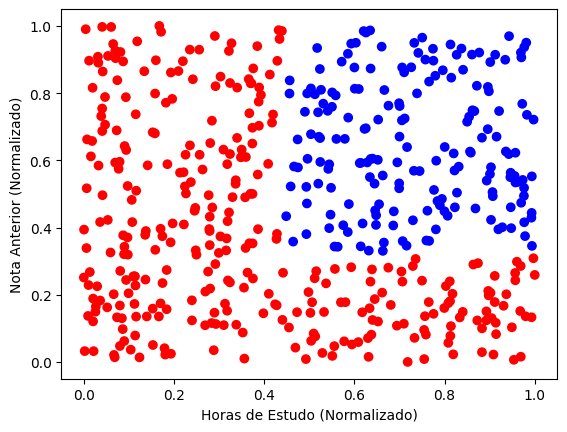

In [14]:
df = pd.read_csv(csv_path)

print("Distribuição das classes:")
print(df['Pass/Fail'].value_counts())

X = df[['Study Hours', 'Previous Exam Score']].values
Y = df['Pass/Fail'].values

# Normalização (Min-Max)
Xc = X - X.min(axis=0)
Xs = Xc.max(axis=0)
Xc = Xc / Xs

# Visualizando os dados normalizados (0 = Vermelho, 1 = Azul)
colors = np.array(['r', 'b'])
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y])
plt.xlabel('Horas de Estudo (Normalizado)')
plt.ylabel('Nota Anterior (Normalizado)')
plt.show()

### Prepara os dados para o PyTorch

In [34]:
X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

In [18]:
Y_tensor

tensor([0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
        1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
        0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
        1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
        0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,

## Construindo o modelo da rede

A saída da rede é composta por um neurônio para cada classe. A saída é denominada *scores* ou logitos:

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLogisticaRede_2_3.png)

In [19]:
# 2 entradas (Study Hours, Prev Exam Score) e 2 saídas (Fail, Pass)
model = nn.Linear(2, 2)

In [20]:
model.state_dict()

OrderedDict([('weight',
              tensor([[ 0.4140, -0.0218],
                      [-0.6550,  0.0800]])),
             ('bias', tensor([-0.4987,  0.5987]))])

### Fazendo um predict

In [21]:
out = model(Variable(X_tensor[:4, :])) # Testando com 4 amostras
print(out)

tensor([[-0.3590,  0.4095],
        [-0.1140,  0.0145],
        [-0.2007,  0.1413],
        [-0.2677,  0.2702]], grad_fn=<AddmmBackward0>)


### Calculando as probabilidades com Softmax

- [Wikipedia:Softmax_function](https://en.wikipedia.org/wiki/Softmax_function)

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/softmax.png)

In [25]:
F.softmax(out,dim=1)

tensor([[0.3168, 0.6832],
        [0.4679, 0.5321],
        [0.4153, 0.5847],
        [0.3687, 0.6313]], grad_fn=<SoftmaxBackward0>)

### Predição da classe

In [26]:
prob, y_pred = torch.max(F.softmax(out, dim=1), dim=1)
print(y_pred)
print(prob)

tensor([1, 1, 1, 1])
tensor([0.6832, 0.5321, 0.5847, 0.6313], grad_fn=<MaxBackward0>)


## Treinamento

### Classe para visualização dinâmica

In [27]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)
    return predicts.data.numpy()

def predict_prob(model, inputs):
    outputs = model(Variable(inputs))
    outputs = F.softmax(outputs, dim=1)
    predicts, _ = torch.max(outputs, 1)
    return predicts.data.numpy()

class MyPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        # Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(12, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 3, 1)
        self.ax1.set_xlim(0, n_epoch)
        self.ax1.set_xlabel('Época', fontsize=16)
        self.ax1.set_ylabel('Perda', fontsize=16)
        self.ax1.set_title('Perda x Época')
        self.ax1.plot([],[], 'b', linewidth=2.0, label="Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 3, 2)
        self.ax2.set_xlim(X[:,0].min(), X[:,0].max())
        self.ax2.set_ylim(X[:,1].min(), X[:,1].max())
        self.ax2.set_xlabel('Horas de Estudo', fontsize=16)
        self.ax2.set_ylabel('Nota Anterior', fontsize=16)
        self.ax2.set_title('Fronteiras de decisão')

        self.ax3 = self.fig.add_subplot(1, 3, 3)
        self.ax3.set_xlim(X[:,0].min(), X[:,0].max())
        self.ax3.set_ylim(X[:,1].min(), X[:,1].max())
        self.ax3.set_xlabel('Horas de Estudo', fontsize=16)
        self.ax3.set_ylabel('Nota Anterior', fontsize=16)
        self.ax3.set_title('Máxima probabilidade')

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch % 250 == 0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth=2.0)

                Zc = predict(self.model, torch.FloatTensor(self.X_grid))
                Zc = Zc.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Zc, cmap=plt.cm.Paired)
                colors = np.array(['r', 'b']) # Modificado para 2 cores
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                Zp = predict_prob(self.model, torch.FloatTensor(self.X_grid))
                Zp = Zp.reshape(self.xx.shape)

                self.ax3.pcolormesh(self.xx, self.yy, Zp, cmap=plt.cm.magma)
                self.ax3.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

### Laço principal de treinamento da Regressão Logística por Softmax

In [28]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

Final loss: 0.2693021595478058


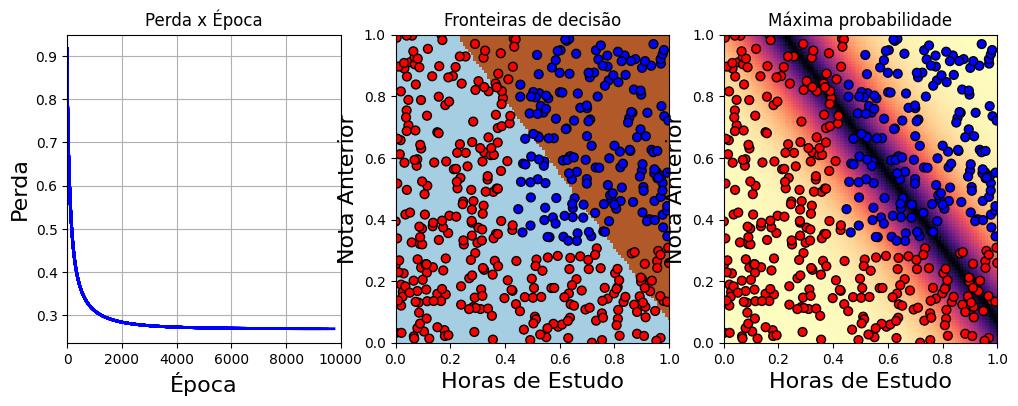

In [29]:
nb_epoch = 10000

# Definindo o plotter
my_plot = MyPlotter(model, Xc, Y, nb_epoch)

losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    # calcula a perda
    loss = criterion(output, Variable(Y_tensor))

    # Faz o backpropagation para calcular os gradientes e otimizar parâmetros
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data.item())

    my_plot.on_epoch_end(i, {'loss': loss.data.item()})

final_loss = loss.data.item()
print('Final loss:', final_loss)

## Avaliação

### Parâmetros após treinamento

In [30]:
model.state_dict()

OrderedDict([('weight',
              tensor([[-5.0191, -4.0737],
                      [ 4.7781,  4.1318]])),
             ('bias', tensor([ 5.2404, -5.1403]))])

### Salvando os parâmetros treinados

In [31]:
os.makedirs('../models', exist_ok=True)
torch.save(model.state_dict(), '../models/RegrLog_Student.pt')

### Exatidão (acurácia) do classificador

Acurácia indica o número de acertos sobre o número total de amostras

In [32]:
Y_pred = predict(model, X_tensor)
accuracy = (Y_pred == Y).mean()
print('Training Accuracy: ', accuracy)

Training Accuracy:  0.868


### Matriz de confusão

In [33]:
pd.crosstab(Y_pred, Y, rownames=['Predito'], colnames=['Real'])

Real,0,1
Predito,,
0,284,34
1,32,150


#Observações

Durante a execução desse trabalho, fica evidente algumas diferenças desse dataset para o dataset Iris.

Aqui temos 2 classes (Fail e Pass), diferente do dataset Iris que tem 3 classes diferentes.

A estrutura da rede é bastante parecida, mas precisei mudar de nn.Linear(2, 3) para nn.Linear(2, 2) porque antes a saída eram 3 tipos de flores e agora foi Fail ou Pass.

No dataset Iris, caso o modelo errasse a previsão isso significaria classificar uma flor em uma espécie diferente. Nesse caso de agora, caso o modelo erre, significa duas coisas diferentes: Falso positivo (32) significa que o modelo previu que os alunos seriam aprovados mas eles reprovaram, e o falso negativo (34) significa que o modelo previu que os alunos não seriam aprovados mas os alunos foram aprovados.

Na construção das classes para vizualização dinâmica eu utilizei o auxílio do Claude.